# Chromatin at replication time: Early vs Late Replicating Origins

May 3, 2024

**Goal:** Identify differences in early and late firing origins. What patterns or signals in the chromatin can be discerned at replication time. Are early replicating genes distinct from late replicating?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
repl_timing_file = 'datasets/computed_mnase/all_repl_timing_deconvolved.csv'
repl_timing = pd.read_csv(repl_timing_file).set_index('orf_name')
print(len(repl_timing), " genes with replication profiles")

repl_timing.head()


5250  genes with replication profiles


,timing,H_index
orf_name,,
YAL067W-A,53.314585,196
YAL067C,52.304185,194
YAL064C-A,52.809385,195
YAL064W,51.798985,193
YAL063C-A,51.798985,193


In [3]:
from src.replication_deconvolution_solver import plot_chrom_repl_timing_from_data

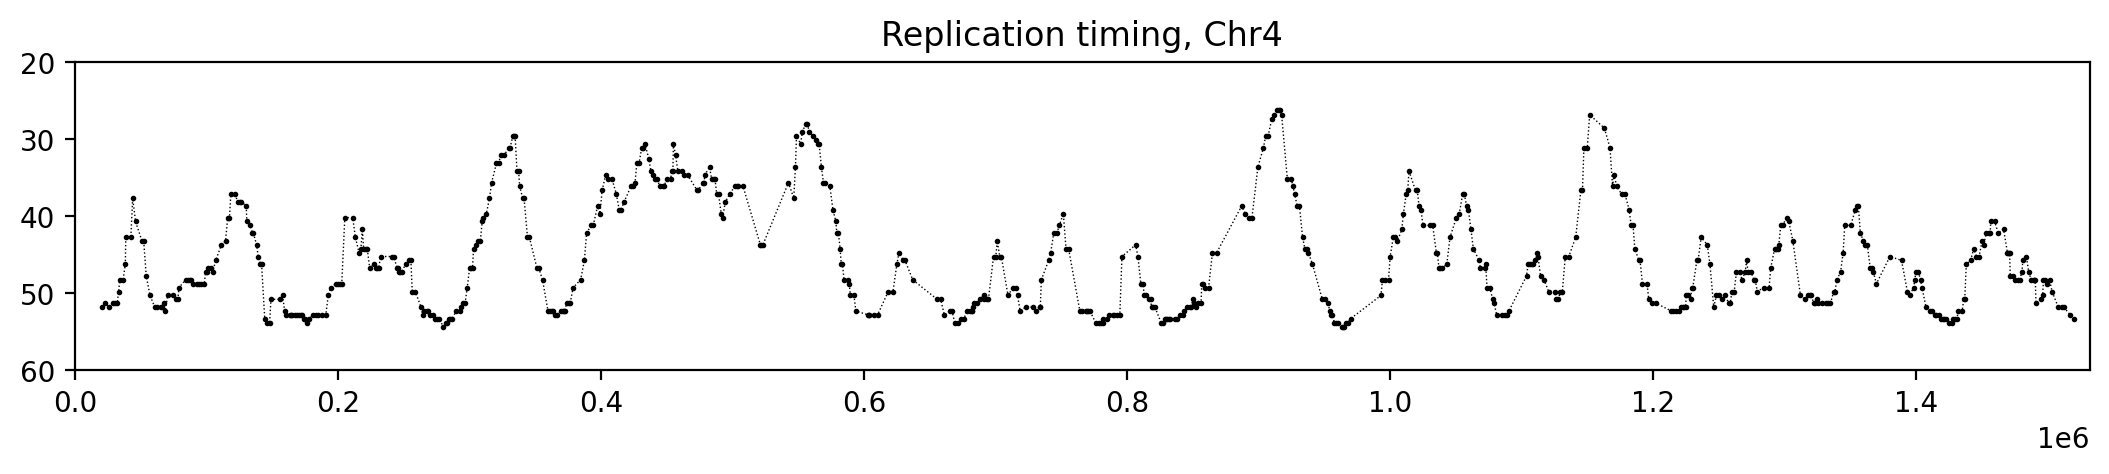

In [4]:
from src.geneset import get_deconvolved_geneset
geneset = get_deconvolved_geneset()

chrom = 4
plot_chrom_repl_timing_from_data(repl_timing, geneset, chrom)

In [5]:
from src.promoter_ptr_analysis import PromoterPTRAnalysis

chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
promoter_analysis = PromoterPTRAnalysis(chromatin_dir)
promoter_analysis.load_f_files()

Shape of the loaded F: (227, 200)
1/5574 - 00:00:00.007
1001/5574 - 00:00:04.983
2001/5574 - 00:00:10.744
3001/5574 - 00:00:16.201
4001/5574 - 00:00:21.734
5001/5574 - 00:00:27.584


In [6]:
promoter_analysis.correct_f_images_by_strand()

In [7]:
# Let's get the gene expression at the replication time.

from src.gene_expression_deconv_analysis import GeneExpressionAnalysis

ge_analysis = GeneExpressionAnalysis(
    'output/deconvolve_combined_g_opt_2024_03_14/gene_expression/')
ge_analysis.load_gene_expression_fs()


# Which genes to start with?

Options:

Many genes, all genes compute the chromatin (some delta) before and after replication
- Prior-replication fork
- Post-replication fork

Early vs Late
High vs Low Gene expression


In [8]:
from src.gene_chromatin_replication_analysis import GeneChromatinReplicationAnalysis

gene_chrom_repl_analysis = GeneChromatinReplicationAnalysis(promoter_analysis,
                                                            ge_analysis,
                                                            repl_timing)

5232 genes with replication timing
Shape of the f images:  (5232, 227, 8, 25)


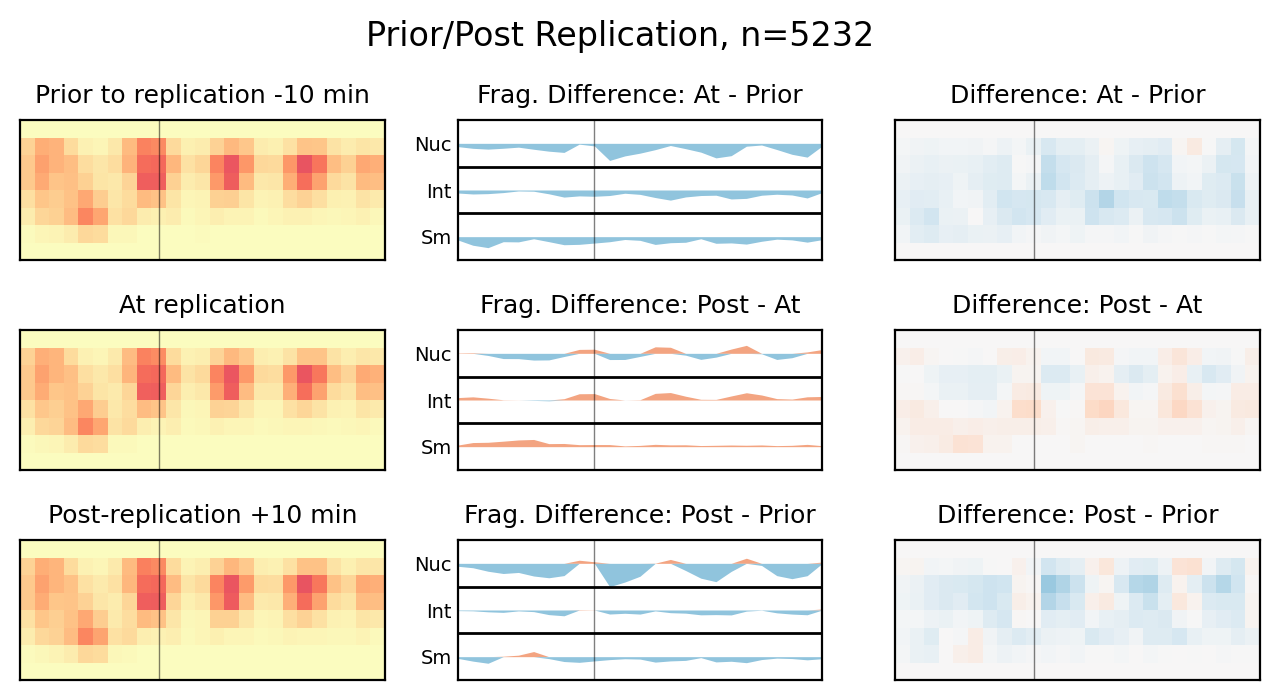

In [9]:
delta_ind = 20

gene_chrom_repl_analysis.select_subset(delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images()

In [17]:
repl_timing_values = gene_chrom_repl_analysis.geneset_repl.replication_timing
repl_timing_values = repl_timing_values.sort_values()

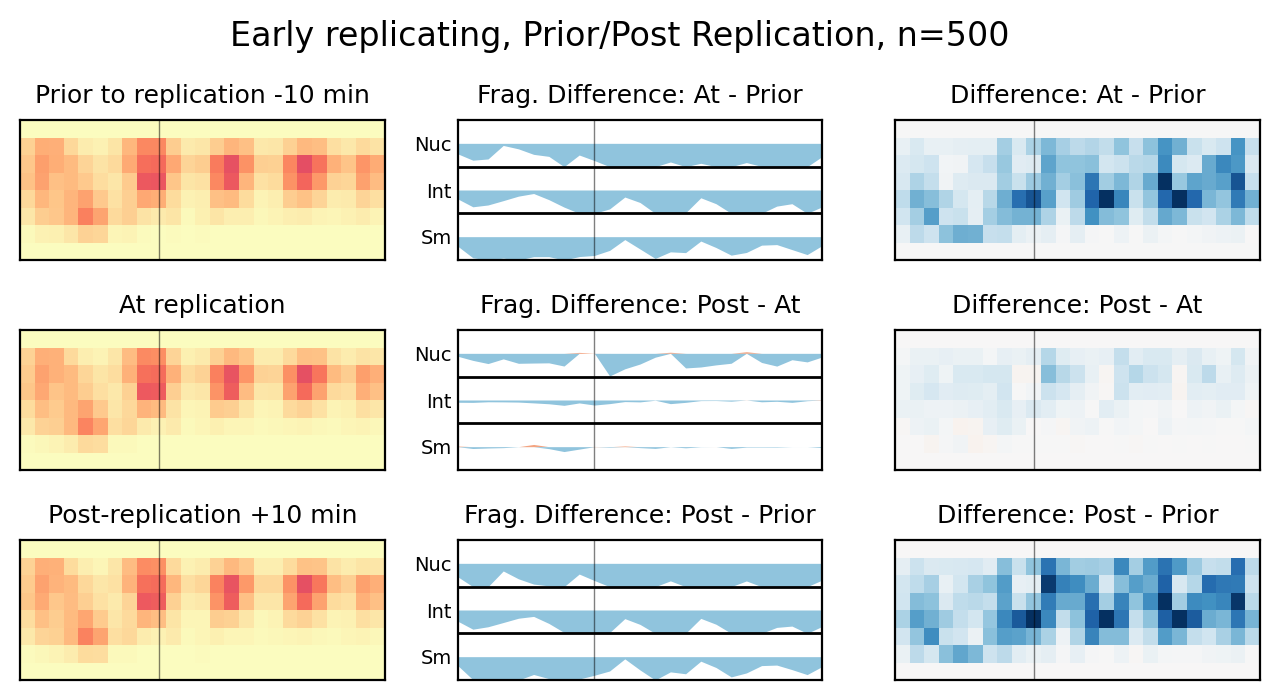

In [18]:
k = 500
gene_chrom_repl_analysis.select_subset(subset_orfs=repl_timing_values.head(k).index, 
                                       delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images(title="Early replicating")

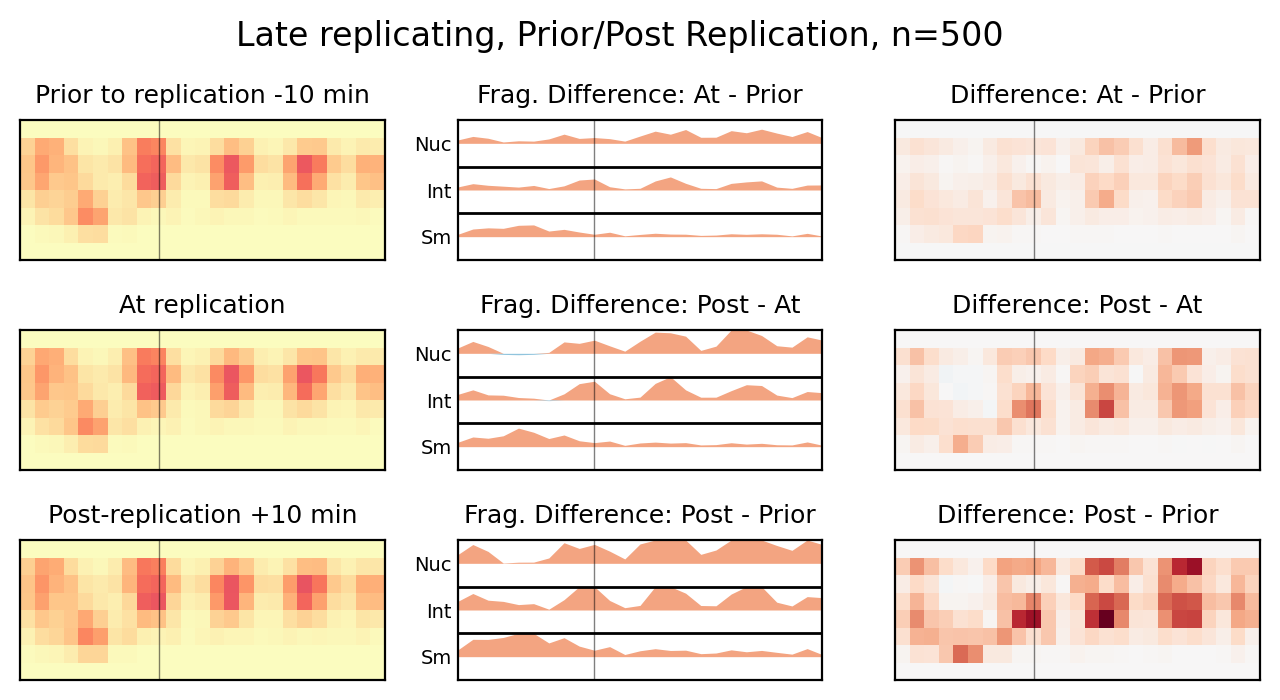

In [19]:
gene_chrom_repl_analysis.select_subset(subset_orfs=repl_timing_values.tail(k).index, 
                                       delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images(title="Late replicating")

In [238]:
# Analysis of nucleosome entropy wrt to replication timing

In [143]:
from src.helpers import calc_entropy

In [240]:
def get_gene_nuc_entropy(geneset_sorted_by_repl, orf_names):

    genes = geneset.loc[orf_names]
    gene_f_images = gene_chrom_repl_analysis.\
        sc_f_w_repl_images[genes.f_gene_index].astype(float)

    config = gene_chrom_repl_analysis.config
    t_indices = config.get_Hpositions_for_branch('t')

    small_lens, med_lens, nuc_lens = yl_rep2_len_spans()
    nuc_bins = nuc_lens[0]//GlobalConstants.BIN_HEIGHT, \
        nuc_lens[1]//GlobalConstants.BIN_HEIGHT

    # Get the nucleosomes for all genes and collapse the fragment length dimension
    nucs_over_time = gene_f_images[:, t_indices, nuc_bins[0]:nuc_bins[1]].sum(axis=2)
    nucs_over_time = nucs_over_time.astype(float)
    nucs_over_time[np.isnan(nucs_over_time)] = 0.
    gene_nuc_entropy = np.apply_along_axis(calc_entropy, 2, nucs_over_time)

    # Z-score normalization
    normalized_gene_nuc_entropy = (gene_nuc_entropy - gene_nuc_entropy.mean(axis=1)\
                                .reshape((-1, 1))) / \
                                gene_nuc_entropy.std(axis=1).reshape((-1, 1))
    return gene_nuc_entropy, normalized_gene_nuc_entropy

In [266]:
def get_repl_positions_in_t(indices_in_t_of_replication):
    config = gene_chrom_repl_analysis.config
    t_timepoints = config.get_timepoints_for_branch('t')
    h_positions = config.get_Hpositions_for_branch('t')
    ret_indices = indices_of_mapping_array(h_positions, 
        indices_in_t_of_replication)
    return ret_indices


In [277]:
def plot_hm(geneset_data, nuc_entropy, title):

    plt.figure(figsize=(6, 6))

    indices_of_repl = get_repl_positions_in_t(geneset_data.replication_H_index.values)

    plt.imshow(nuc_entropy, aspect='auto', cmap='RdBu_r', vmin=-3,
               vmax=3)

    plt.xlabel("Deconvolved time along mother branch, min")
    plt.xlabel("Deconvolved time, mother branch")
    plt.ylabel("Genes sorted by replication time")

    ys = np.arange(len(geneset_data))
    plt.scatter(indices_of_repl, ys, s=0.5, c='black', marker='D')
    plt.title(f"{title}, n={len(ys)}")
    

In [ ]:
geneset_sorted_by_repl = gene_chrom_repl_analysis.geneset_repl.sort_values(
    'replication_timing')
orf_names = geneset_sorted_by_repl.index
gene_nuc_entropy,\
    normalized_gene_nuc_entropy = get_gene_nuc_entropy(geneset_sorted_by_repl, orf_names)

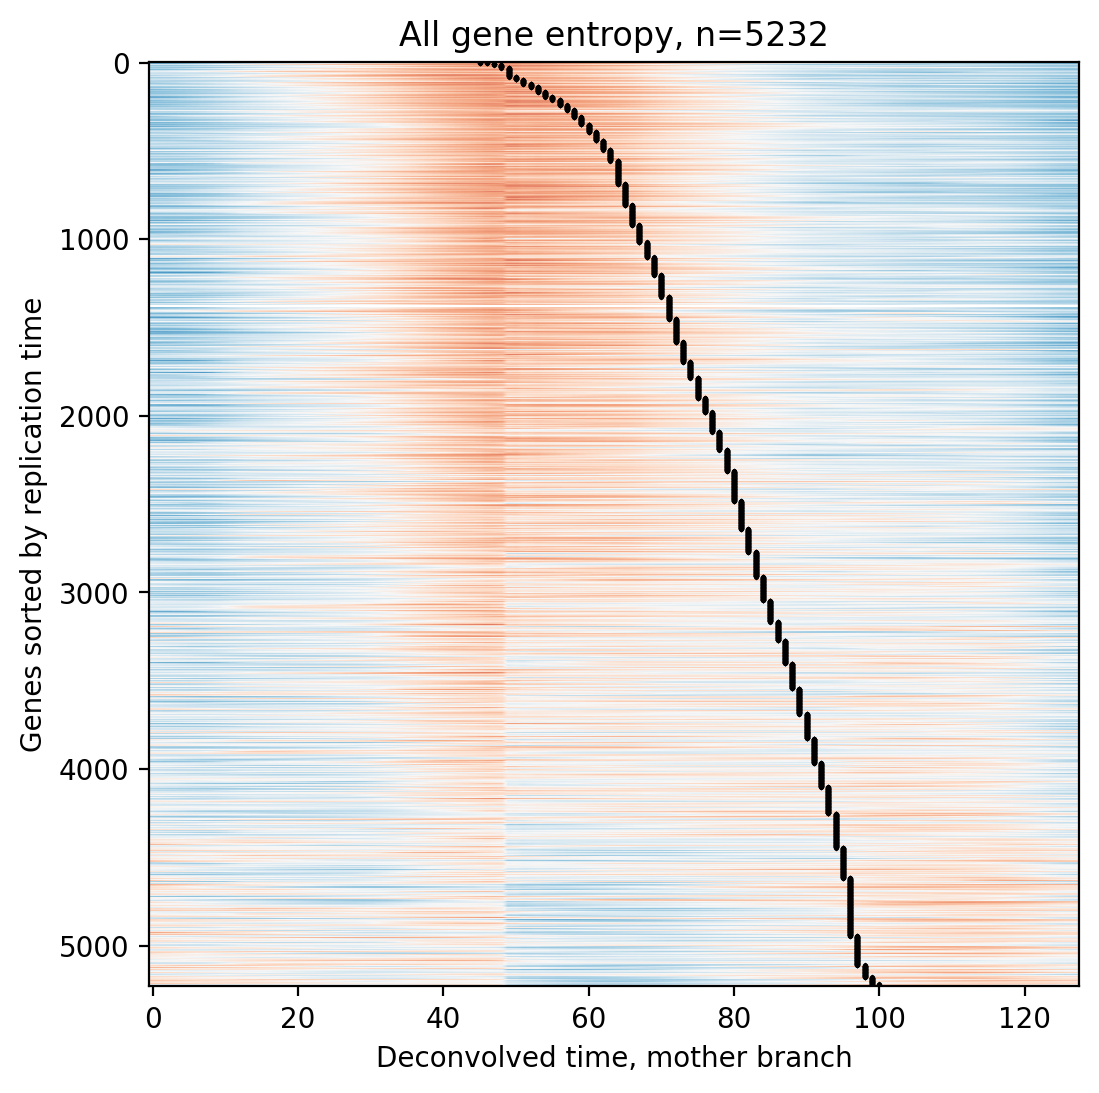

In [278]:
plot_hm(geneset_sorted_by_repl, normalized_gene_nuc_entropy, title="All gene entropy")

In [295]:
k = 500

highly_expressed_genes = geneset_sorted_by_repl.sort_values('expression_at_replication')\
    .head(k)
highly_expressed_genes = highly_expressed_genes.sort_values('replication_timing')

lowly_expressed_genes = geneset_sorted_by_repl.sort_values('expression_at_replication')\
    .tail(k)
lowly_expressed_genes = lowly_expressed_genes.sort_values('replication_timing')


In [296]:
orf_names = highly_expressed_genes.index
_, high_norm_nuc_entropy = get_gene_nuc_entropy(highly_expressed_genes, orf_names)

orf_names = lowly_expressed_genes.index
_, lowly_norm_nuc_entropy = get_gene_nuc_entropy(lowly_expressed_genes, orf_names)

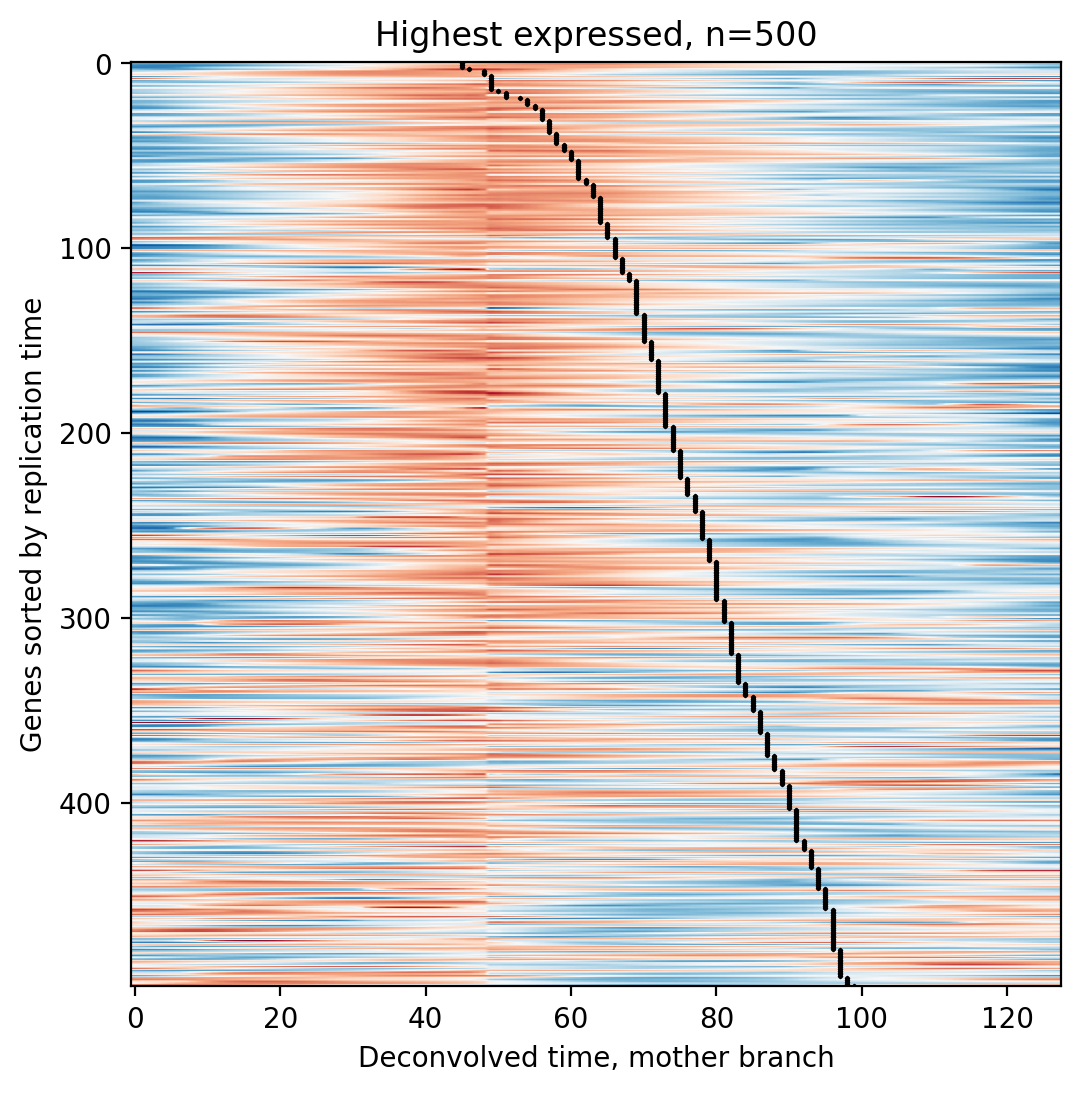

In [297]:
plot_hm(lowly_expressed_genes, lowly_norm_nuc_entropy, title="Highest expressed")

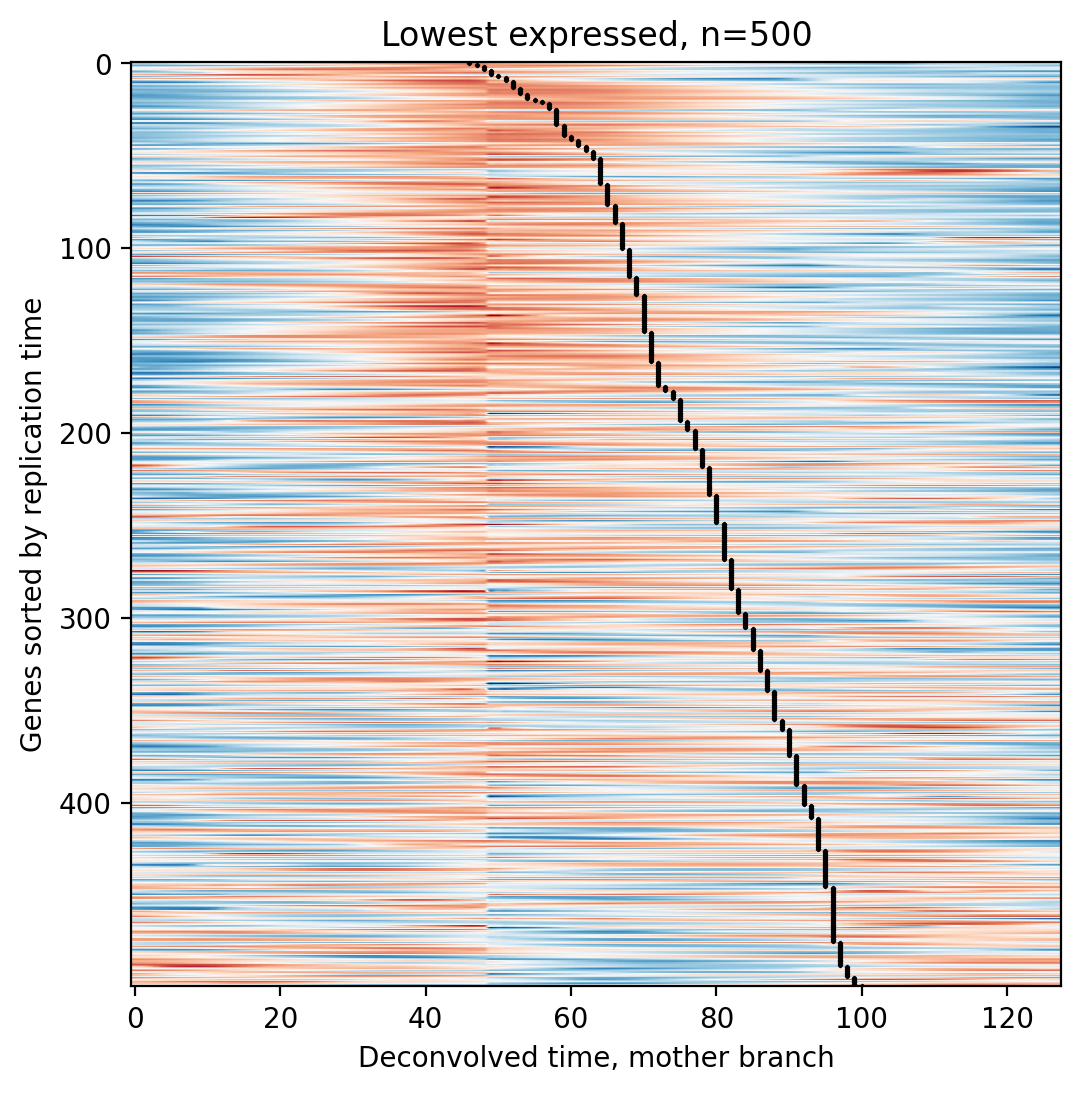

In [298]:
plot_hm(highly_expressed_genes, high_norm_nuc_entropy, title="Lowest expressed")